In [1]:
from pathlib import Path
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml
import re


def resolve_project_root() -> Path:
    """Возвращает корень проекта для запуска из notebooks или из корня."""
    root = Path.cwd()
    if not (root / "results").exists() and (root.parent / "results").exists():
        root = root.parent
    return root


def load_wgan_histories(results_dir: Path) -> pd.DataFrame:
    """Считывает историю обучения из новой и старой структуры results."""
    frames = []
    for first_level_dir in sorted(results_dir.iterdir()):
        if not first_level_dir.is_dir():
            continue

        legacy_history_path = first_level_dir / "wgan_training_history.csv"
        if legacy_history_path.exists():
            run_df = pd.read_csv(legacy_history_path)
            if "epoch" in run_df.columns:
                run_df["run_name"] = "legacy"
                run_df["config"] = first_level_dir.name
                run_df["run_id"] = first_level_dir.name
                if "global_step" not in run_df.columns:
                    run_df["global_step"] = run_df["epoch"]
                frames.append(run_df)
            continue

        for config_dir in sorted(first_level_dir.iterdir()):
            if not config_dir.is_dir():
                continue
            history_path = config_dir / "wgan_training_history.csv"
            if not history_path.exists():
                continue
            run_df = pd.read_csv(history_path)
            if "epoch" not in run_df.columns:
                continue
            run_df["run_name"] = first_level_dir.name
            run_df["config"] = config_dir.name
            run_df["run_id"] = f"{first_level_dir.name}/{config_dir.name}"
            if "global_step" not in run_df.columns:
                run_df["global_step"] = run_df["epoch"]
            frames.append(run_df)

    if not frames:
        raise FileNotFoundError(f"Не найдены файлы wgan_training_history.csv в {results_dir}")

    df = pd.concat(frames, ignore_index=True)
    df = df.sort_values(["run_id", "epoch"]).reset_index(drop=True)
    return df


def plot_metric_by_epoch(
    metric: str,
    result_subdir: str,
    runs: Optional[Iterable[str]] = None,
    run_names: Optional[Iterable[str]] = None,
    results_dir: Optional[Path] = None,
    x_axis: str = "epoch",
    figsize=(12, 6),
    optimize: str = "min",
):
    """Строит зависимость метрики от эпохи/шага и печатает лучшее значение метрики."""
    if x_axis not in {"epoch", "global_step"}:
        raise ValueError("x_axis должен быть 'epoch' или 'global_step'")
    if optimize not in {"min", "max"}:
        raise ValueError("optimize должен быть 'min' или 'max'")

    project_root = resolve_project_root()
    if results_dir is None:
        base_results_dir = project_root / "results"
        if result_subdir is not None:
            base_results_dir = base_results_dir / result_subdir
    else:
        base_results_dir = results_dir
    df = load_wgan_histories(base_results_dir)

    metric_columns = [col for col in df.columns if col not in {"epoch", "global_step", "run_name", "config", "run_id"}]
    if metric not in metric_columns:
        raise ValueError(f"Метрика '{metric}' не найдена. Доступные: {metric_columns}")

    if run_names is not None:
        run_names = list(run_names)
        df = df[df["run_name"].isin(run_names)].copy()
        if df.empty:
            raise ValueError(f"Для run_names={run_names} не найдено данных")

    if runs is not None:
        runs = list(runs)
        df = df[df["run_id"].isin(runs)].copy()
        if df.empty:
            raise ValueError(f"Для runs={runs} не найдено данных")

    plt.figure(figsize=figsize)
    sns.lineplot(data=df, x=x_axis, y=metric, hue="run_id", marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.title("RMSE by Epoch")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    best_idx = df[metric].idxmin() if optimize == "min" else df[metric].idxmax()
    best_row = df.loc[best_idx]
    print(
        f"Best ({optimize}) {metric}: {best_row[metric]:.6f} | "
        f"run={best_row['run_id']} | {x_axis}={best_row[x_axis]}"
    )


def extract_param_from_config(config_path: Path, param_name: str) -> Optional[float]:
    """Извлекает значение параметра из конфига."""
    try:
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
        
        if param_name == "n_events":
            return float(config.get("aging", {}).get("n_events"))
        elif param_name == "batch_size":
            return float(config.get("wgan_params", {}).get("batch_size"))
        elif param_name == "epochs":
            return float(config.get("wgan_params", {}).get("epochs"))
        elif param_name == "lr":
            return float(config.get("wgan_params", {}).get("lr"))
        elif param_name == "gp_lambda":
            return float(config.get("wgan_params", {}).get("gp_lambda"))
        else:
            def find_in_dict(d, key):
                if key in d:
                    return d[key]
                for v in d.values():
                    if isinstance(v, dict):
                        result = find_in_dict(v, key)
                        if result is not None:
                            return result
                return None
            
            result = find_in_dict(config, param_name)
            if result is not None:
                return float(result)
    except Exception as e:
        pass
    
    config_name = config_path.stem
    if param_name == "n_events":
        match = re.search(r'n(\d+)', config_name)
        if match:
            return float(match.group(1))
    elif param_name == "batch_size":
        match = re.search(r'b(\d+)', config_name)
        if match:
            return float(match.group(1))
    
    return None


def plot_best_metric_vs_param(
    metric: str,
    run_dir: str,
    param_name: str = "n_events",
    optimize: str = "min",
    results_dir: Optional[Path] = None,
    experiment_name: Optional[str] = None,
    figsize=(10, 6),
    exclude_param_values: Optional[Iterable[float]] = None,
    baseline_point: Optional[tuple] = None,
):
    """Строит график лучшей метрики в зависимости от параметра конфига.
    
    Args:
        metric: Название метрики (например, "W_rmse")
        run_dir: Директория запуска (например, "run_n_events")
        param_name: Название параметра для оси X (по умолчанию "n_events")
        optimize: "min" или "max" - что оптимизируем
        results_dir: Опциональный путь к results (если None, берется из project_root)
        experiment_name: Опциональное имя эксперимента (если None, берется из структуры)
        figsize: Размер графика
        exclude_param_values: Значения param_name, которые нужно исключить с графика
        baseline_point: Опциональная точка (x, y) для отображения baseline на графике
    """
    if optimize not in {"min", "max"}:
        raise ValueError("optimize должен быть 'min' или 'max'")
    
    project_root = resolve_project_root()
    if results_dir is None:
        base_results_dir = project_root / "results" / run_dir
    else:
        base_results_dir = results_dir / run_dir
    
    if not base_results_dir.exists():
        raise FileNotFoundError(f"Директория {base_results_dir} не найдена")
    
    df = load_wgan_histories(base_results_dir)
    
    metric_columns = [col for col in df.columns if col not in {"epoch", "global_step", "run_name", "config", "run_id"}]
    if metric not in metric_columns:
        raise ValueError(f"Метрика '{metric}' не найдена. Доступные: {metric_columns}")
    
    best_by_config = []
    
    for config_name in df["config"].unique():
        config_df = df[df["config"] == config_name].copy()
        if config_df.empty:
            continue
        
        best_idx = config_df[metric].idxmin() if optimize == "min" else config_df[metric].idxmax()
        best_row = config_df.loc[best_idx]
        
        config_path = None
        if experiment_name:
            config_path = project_root / "configs" / "generated" / experiment_name / f"{config_name}.yaml"
        else:
            found_exp_name = None
            for exp_dir in base_results_dir.iterdir():
                if exp_dir.is_dir() and (exp_dir / config_name).is_dir():
                    found_exp_name = exp_dir.name
                    break
            
            if found_exp_name:
                config_path = project_root / "configs" / "generated" / found_exp_name / f"{config_name}.yaml"
        
        if config_path is None or not config_path.exists():
            for gen_dir in (project_root / "configs" / "generated").iterdir():
                if gen_dir.is_dir():
                    potential_path = gen_dir / f"{config_name}.yaml"
                    if potential_path.exists():
                        config_path = potential_path
                        break
        
        param_value = None
        if config_path and config_path.exists():
            param_value = extract_param_from_config(config_path, param_name)
        
        if param_value is not None:
            best_by_config.append({
                "config": config_name,
                "param_value": param_value,
                "best_metric": best_row[metric],
                "epoch": best_row["epoch"],
            })
    
    if not best_by_config:
        raise ValueError(f"Не удалось извлечь параметр '{param_name}' ни для одного конфига")
    
    best_df = pd.DataFrame(best_by_config)
    best_df = best_df.sort_values("param_value")

    if exclude_param_values is not None:
        excluded = set(float(v) for v in exclude_param_values)
        best_df = best_df[~best_df["param_value"].isin(excluded)].copy()

    if best_df.empty:
        raise ValueError("После фильтрации не осталось данных для построения графика")

    if baseline_point is not None:
        import numpy as np
        xs = np.concatenate([[baseline_point[0]], best_df["param_value"].values])
        ys = np.concatenate([[baseline_point[1]], best_df["best_metric"].values])
        sort_idx = np.argsort(xs)
        xs, ys = xs[sort_idx], ys[sort_idx]
    else:
        xs, ys = best_df["param_value"].values, best_df["best_metric"].values

    plt.figure(figsize=figsize)
    plt.plot(xs, ys, marker="o", linewidth=2, markersize=8)
    plt.xlabel(f"{param_name}")
    plt.ylabel("RMSE")
    plt.title(f"RMSE VS {param_name}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    best_overall_idx = best_df["best_metric"].idxmin() if optimize == "min" else best_df["best_metric"].idxmax()
    best_overall = best_df.loc[best_overall_idx]
    print(
        f"Best overall ({optimize}) {metric}: {best_overall['best_metric']:.6f} | "
        f"{param_name}={best_overall['param_value']} | config={best_overall['config']}"
    )

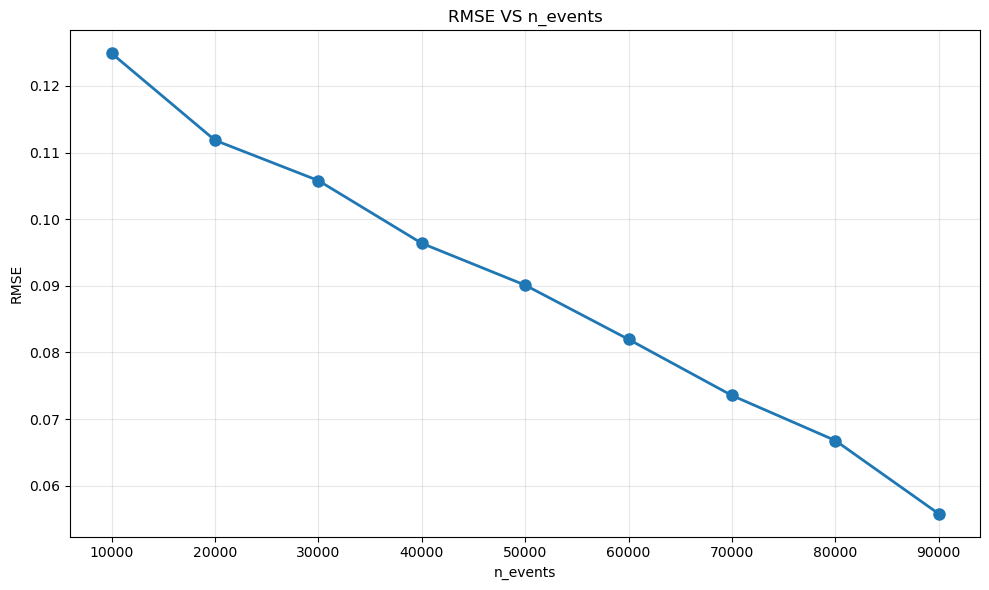

Best overall (min) W_rmse: 0.055802 | n_events=90000.0 | config=config_n90000


In [3]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_ws_final",
    param_name="n_events",
    optimize="min",
    experiment_name="ws_final"
)

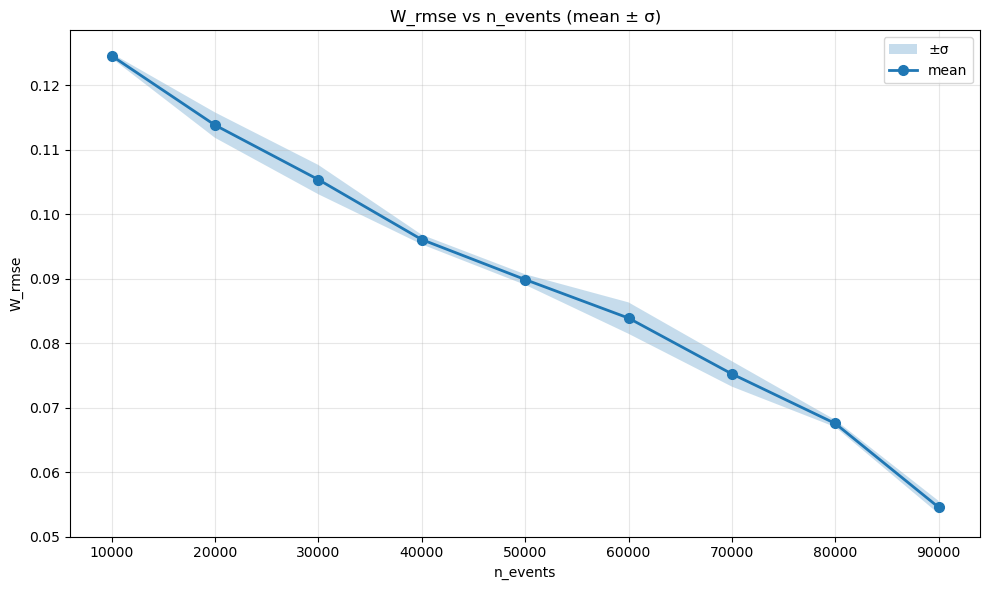

 param_value  ws_final  ws_final_seed_1  ws_final_seed_2     mean      std       lo       hi
     10000.0  0.124887         0.124812         0.124057 0.124585 0.000375 0.124210 0.124960
     20000.0  0.111845         0.113137         0.116514 0.113832 0.001969 0.111863 0.115801
     30000.0  0.105794         0.102410         0.107929 0.105378 0.002273 0.103105 0.107650
     40000.0  0.096382         0.095058         0.096800 0.096080 0.000742 0.095338 0.096822
     50000.0  0.090105         0.090747         0.088786 0.089879 0.000817 0.089063 0.090696
     60000.0  0.081970         0.087338         0.082408 0.083905 0.002434 0.081472 0.086339
     70000.0  0.073545         0.078003         0.074180 0.075243 0.001969 0.073274 0.077211
     80000.0  0.066787         0.067831         0.068046 0.067555 0.000550 0.067005 0.068105
     90000.0  0.055802         0.054475         0.053384 0.054554 0.000989 0.053565 0.055542


In [4]:
import numpy as np


def plot_best_metric_vs_param_multi_seed(
    metric: str,
    run_dirs,
    experiment_names,
    labels=None,
    param_name: str = "n_events",
    optimize: str = "min",
    figsize=(10, 6),
    title: Optional[str] = None,
):
    """Строит график mean ± std лучшей метрики по нескольким запускам.

    Для каждого значения param_name берётся лучшее (min/max по эпохам) значение метрики
    в каждом из запусков, затем по запускам считаются mean/std и строится линия
    среднего с залитой областью mean ± std.
    """
    project_root = resolve_project_root()
    run_dirs = list(run_dirs)
    experiment_names = list(experiment_names)
    if labels is None:
        labels = experiment_names

    per_run_curves = []
    for run_dir, experiment_name in zip(run_dirs, experiment_names):
        base_results_dir = project_root / "results" / run_dir
        df = load_wgan_histories(base_results_dir)

        rows = []
        for config_name in df["config"].unique():
            cfg_df = df[df["config"] == config_name]
            idx = cfg_df[metric].idxmin() if optimize == "min" else cfg_df[metric].idxmax()
            best_val = float(cfg_df.loc[idx, metric])

            config_path = project_root / "configs" / "generated" / experiment_name / f"{config_name}.yaml"
            param_value = extract_param_from_config(config_path, param_name)
            if param_value is None:
                continue
            rows.append({"param_value": float(param_value), "best": best_val})

        curve = pd.DataFrame(rows).groupby("param_value", as_index=False)["best"].min()
        curve = curve.rename(columns={"best": experiment_name})
        per_run_curves.append(curve)

    merged = per_run_curves[0]
    for curve in per_run_curves[1:]:
        merged = merged.merge(curve, on="param_value", how="outer")
    merged = merged.sort_values("param_value").reset_index(drop=True)

    value_cols = experiment_names
    merged["mean"] = merged[value_cols].mean(axis=1)
    merged["std"] = merged[value_cols].std(axis=1, ddof=0)
    merged["lo"] = merged["mean"] - merged["std"]
    merged["hi"] = merged["mean"] + merged["std"]

    plt.figure(figsize=figsize)
    xs = merged["param_value"].values
    plt.fill_between(xs, merged["lo"], merged["hi"], alpha=0.25, label="±σ")
    plt.plot(xs, merged["mean"], marker="o", linewidth=2, markersize=7, label="mean")
    plt.xlabel(param_name)
    plt.ylabel(metric)
    plt.title(title or f"{metric} vs {param_name} (mean ± σ)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(merged.to_string(index=False))


plot_best_metric_vs_param_multi_seed(
    metric="W_rmse",
    run_dirs=[
        "run_ws_final",
        "run_ws_final_seed_1",
        "run_ws_final_seed_2"
    ],
    experiment_names=[
        "ws_final",
        "ws_final_seed_1",
        "ws_final_seed_2"
    ],
    labels=["seed 76/93", "seed 12/55", "seed 37/81", "seed 8/71", "seed 43/29"],
    param_name="n_events",
    optimize="min",
)

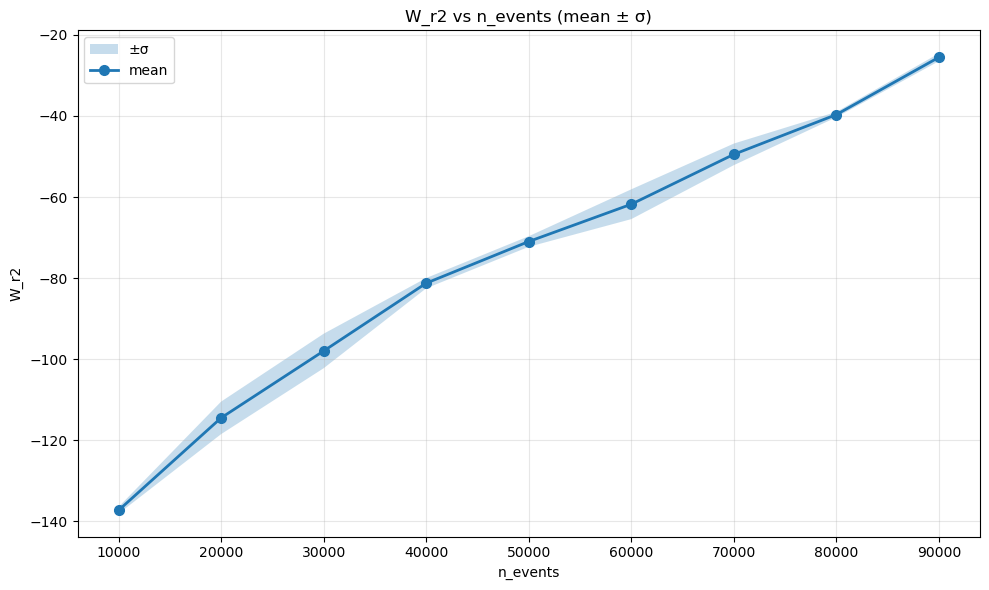

 param_value    ws_final  ws_final_seed_1  ws_final_seed_2        mean      std          lo          hi
     10000.0 -137.915222      -137.749695      -136.075180 -137.246699 0.831141 -138.077840 -136.415558
     20000.0 -110.416283      -113.005875      -119.913887 -114.445348 4.008756 -118.454104 -110.436592
     30000.0  -98.687431       -92.411255      -102.751984  -97.950223 4.253647 -102.203871  -93.696576
     40000.0  -81.739464       -79.481575       -82.457298  -81.226112 1.267906  -82.494019  -79.958206
     50000.0  -71.313164       -72.347015       -69.210426  -70.956868 1.305056  -72.261925  -69.651812
     60000.0  -58.844894       -66.939644       -59.486153  -61.756897 3.674094  -65.430991  -58.082803
     70000.0  -47.175720       -53.191956       -48.010151  -49.459276 2.661296  -52.120571  -46.797980
     80000.0  -38.728081       -39.980507       -40.240501  -39.649696 0.660268  -40.309964  -38.989428
     90000.0  -26.734037       -25.430674       -24.382868  -25.

In [5]:
plot_best_metric_vs_param_multi_seed(
    metric="W_r2",
    run_dirs=[
        "run_ws_final",
        "run_ws_final_seed_1",
        "run_ws_final_seed_2"
    ],
    experiment_names=[
        "ws_final",
        "ws_final_seed_1",
        "ws_final_seed_2"
    ],
    labels=["seed 76/93", "seed 12/55", "seed 37/81", "seed 8/71", "seed 43/29"],
    param_name="n_events",
    optimize="max",
)

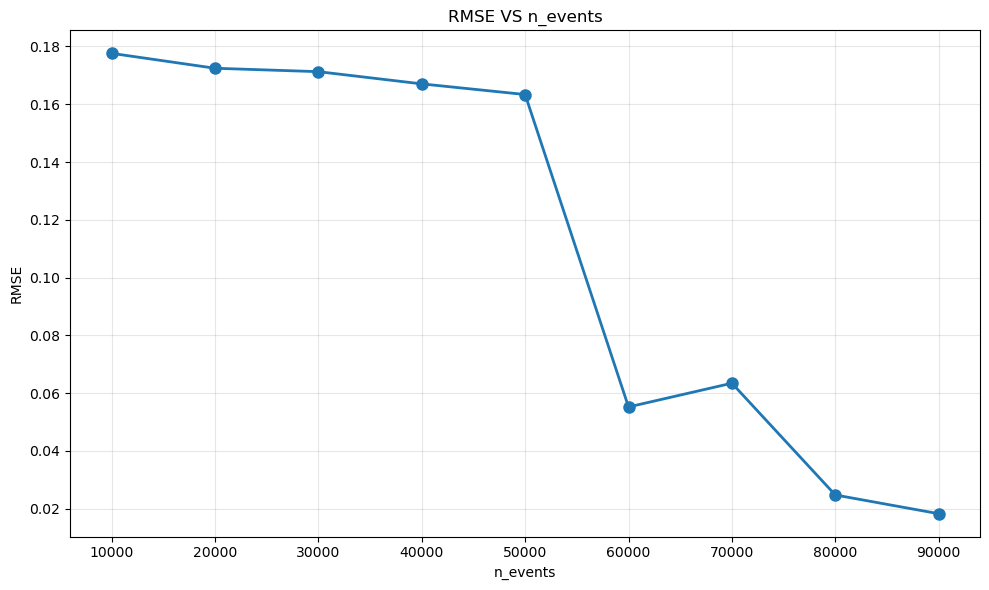

Best overall (min) W_rmse: 0.018291 | n_events=90000.0 | config=config_n90000


In [10]:
plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_wgan_n_critic_5_epochs_200_n_events",
    param_name="n_events",
    optimize="min",
    experiment_name="wgan_n_critic_5_epochs_200_n_events"
)

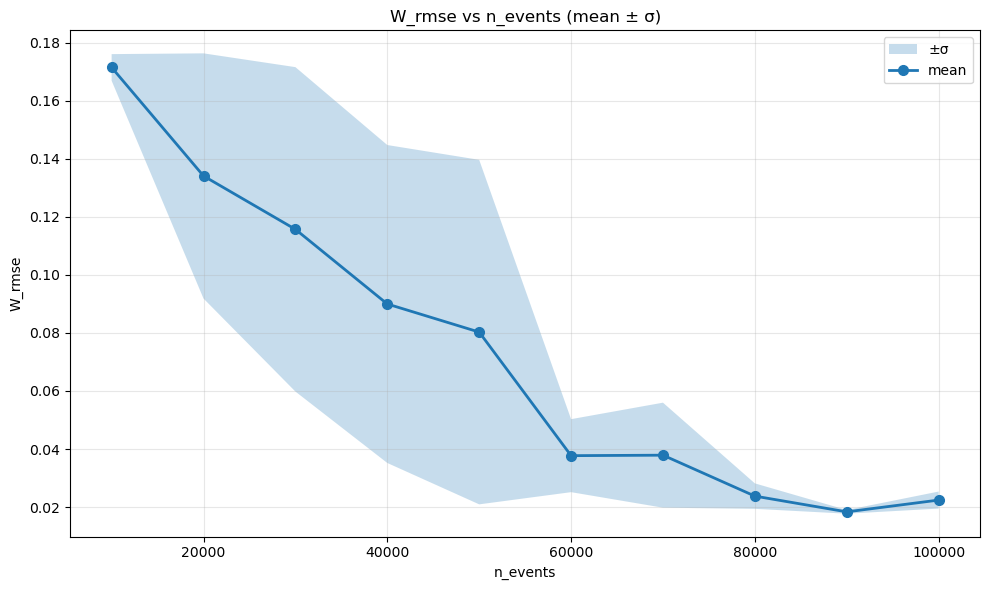

 param_value  wgan_n_critic_5_epochs_200_n_events  wgan_n_critic_5_epochs_200_n_events_seed_1  wgan_n_critic_5_epochs_200_n_events_seed_2     mean      std       lo       hi
     10000.0                             0.177625                                    0.166658                                    0.170046 0.171443 0.004585 0.166858 0.176028
     20000.0                             0.172469                                    0.075253                                    0.154461 0.134061 0.042228 0.091833 0.176289
     30000.0                             0.171285                                    0.039259                                    0.136474 0.115673 0.055870 0.059802 0.171543
     40000.0                             0.167057                                    0.045147                                    0.057666 0.089957 0.054757 0.035200 0.144714
     50000.0                             0.163372                                    0.048832                                    0

In [18]:
plot_best_metric_vs_param_multi_seed(
    metric="W_rmse",
    run_dirs=[
        "run_wgan_n_critic_5_epochs_200_n_events",
        "run_wgan_n_critic_5_epochs_200_n_events_seed_1",
        "run_wgan_n_critic_5_epochs_200_n_events_seed_2",
        "run_wgan_n_critic_5_epochs_200_n_events_seed_3",
        "run_wgan_n_critic_5_epochs_200_n_events_seed_4",
    ],
    experiment_names=[
        "wgan_n_critic_5_epochs_200_n_events",
        "wgan_n_critic_5_epochs_200_n_events_seed_1",
        "wgan_n_critic_5_epochs_200_n_events_seed_2",
        "wgan_n_critic_5_epochs_200_n_events_seed_3",
        "wgan_n_critic_5_epochs_200_n_events_seed_4",
    ],
    param_name="n_events",
    optimize="min",
)


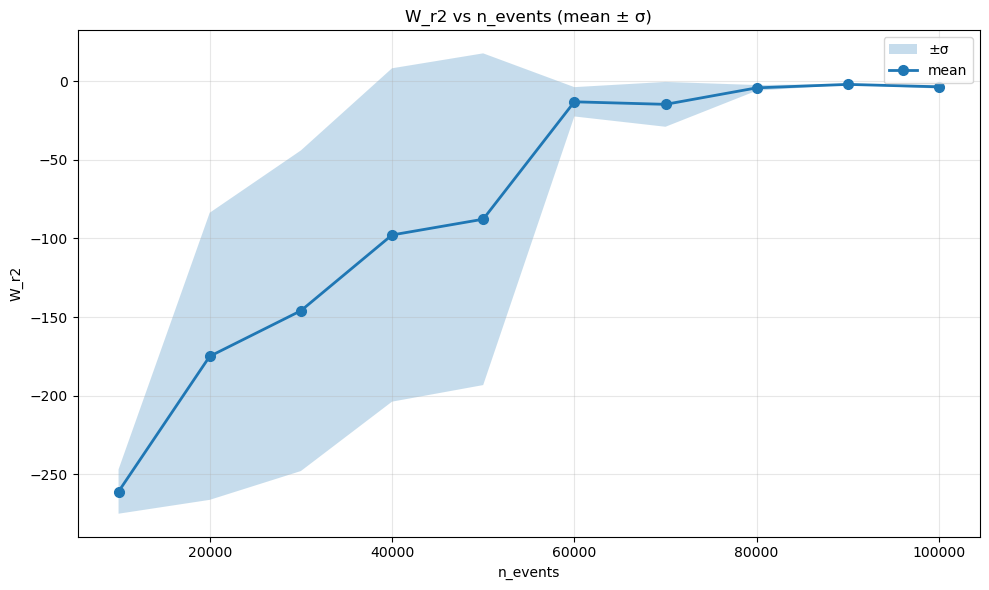

 param_value  wgan_n_critic_5_epochs_200_n_events  wgan_n_critic_5_epochs_200_n_events_seed_1  wgan_n_critic_5_epochs_200_n_events_seed_2        mean        std          lo          hi
     10000.0                          -280.011810                                 -246.381210                                 -256.544281 -260.979101  14.083206 -275.062306 -246.895895
     20000.0                          -263.936218                                  -49.439137                                 -211.496765 -174.957373  91.300219 -266.257592  -83.657155
     30000.0                          -260.311188                                  -12.727719                                 -164.888504 -145.975804 101.956400 -247.932203  -44.019404
     40000.0                          -247.567978                                  -17.154234                                  -28.617998  -97.780070 106.019393 -203.799463    8.239323
     50000.0                          -236.724823                          

In [19]:
plot_best_metric_vs_param_multi_seed(
    metric="W_r2",
    run_dirs=[
        "run_wgan_n_critic_5_epochs_200_n_events",
        "run_wgan_n_critic_5_epochs_200_n_events_seed_1",
        "run_wgan_n_critic_5_epochs_200_n_events_seed_2",
        "run_wgan_n_critic_5_epochs_200_n_events_seed_3",
        "run_wgan_n_critic_5_epochs_200_n_events_seed_4",
    ],
    experiment_names=[
        "wgan_n_critic_5_epochs_200_n_events",
        "wgan_n_critic_5_epochs_200_n_events_seed_1",
        "wgan_n_critic_5_epochs_200_n_events_seed_2",
        "wgan_n_critic_5_epochs_200_n_events_seed_3",
        "wgan_n_critic_5_epochs_200_n_events_seed_4",
    ],
    param_name="n_events",
    optimize="max",
)


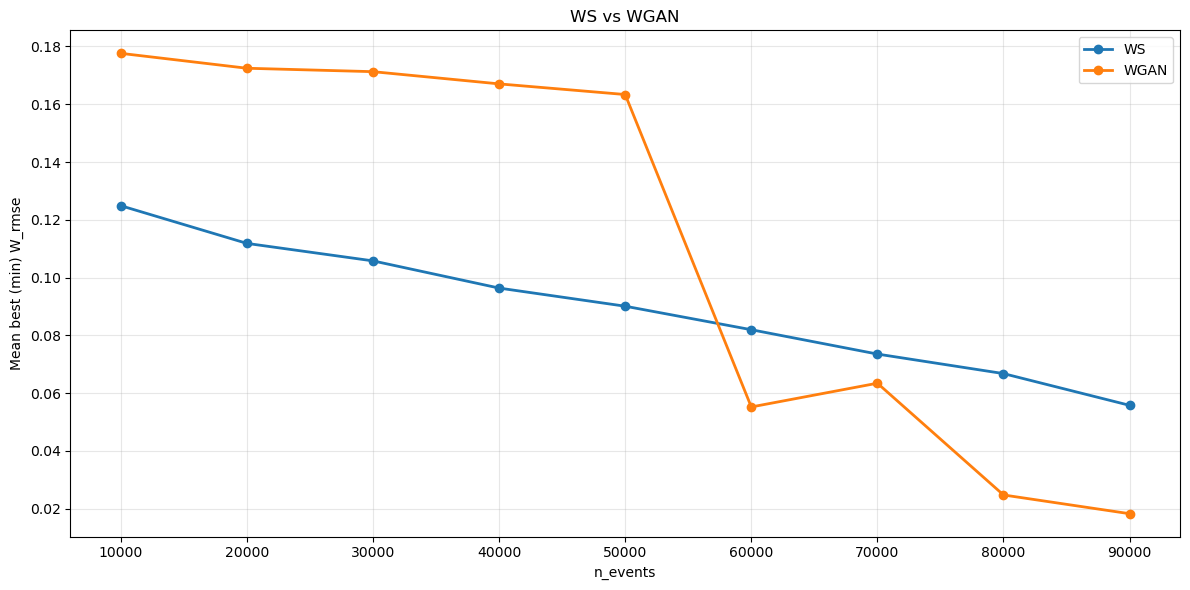

In [20]:
import numpy as np

def _collect_best_curve(run_dir, experiment_name, metric="W_rmse", optimize="min", param_name="n_events"):
    project_root = resolve_project_root()
    base_results_dir = project_root / "results" / run_dir
    df = load_wgan_histories(base_results_dir)

    rows = []
    for config_name in df["config"].unique():
        cfg_df = df[df["config"] == config_name]
        vals = []
        for _, g in cfg_df.groupby("run_id", sort=False):
            if g.empty:
                continue
            idx = g[metric].idxmin() if optimize == "min" else g[metric].idxmax()
            vals.append(float(g.loc[idx, metric]))
        if not vals:
            continue

        config_path = resolve_project_root() / "configs" / "generated" / experiment_name / f"{config_name}.yaml"
        if not config_path.exists():
            continue
        param_value = extract_param_from_config(config_path, param_name)
        if param_value is None:
            continue

        rows.append({"param_value": float(param_value), "y": float(np.mean(vals))})

    return pd.DataFrame(rows).sort_values("param_value")

ws_df = _collect_best_curve("run_ws_final", "ws_final", metric="W_rmse", optimize="min")
wgan_df = _collect_best_curve("run_wgan_n_critic_5_epochs_200_n_events", "wgan_n_critic_5_epochs_200_n_events", metric="W_rmse", optimize="min")

plt.figure(figsize=(12, 6))
plt.plot(ws_df["param_value"], ws_df["y"], marker="o", linewidth=2, label="WS")
plt.plot(wgan_df["param_value"], wgan_df["y"], marker="o", linewidth=2, label="WGAN")
plt.xlabel("n_events")
plt.ylabel("Mean best (min) W_rmse")
plt.title("WS vs WGAN")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

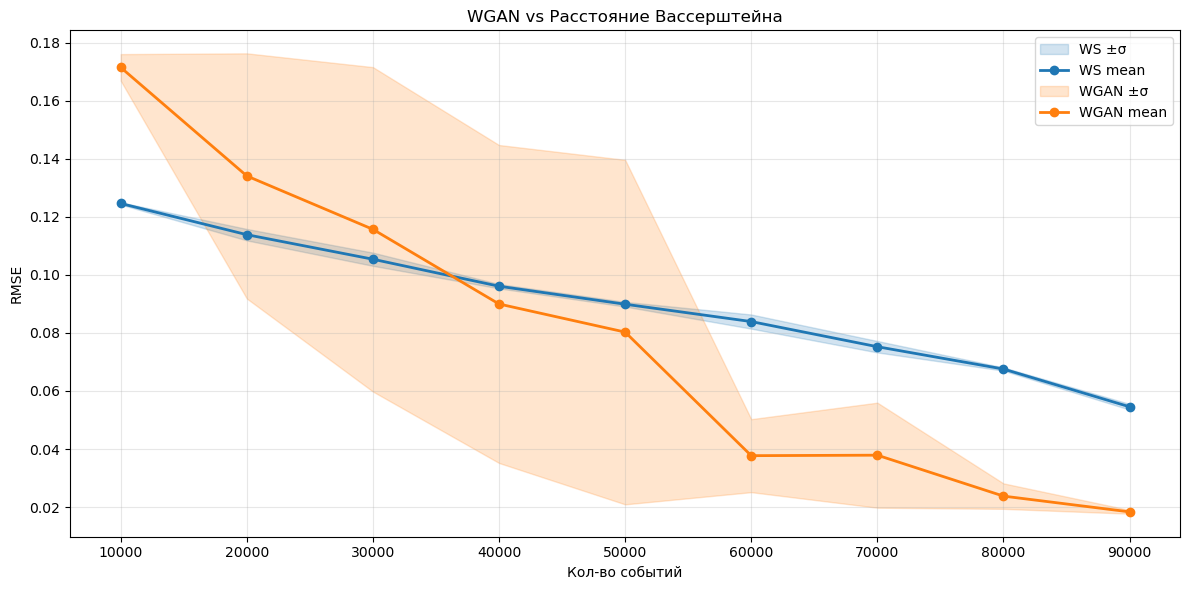

In [21]:
def _collect_seed_curves(run_dirs, experiment_names, metric="W_rmse", optimize="min", param_name="n_events"):
    """Собирает по нескольким сидам лучшие значения метрики и считает mean/min/max по param_value."""
    project_root = resolve_project_root()
    per_run_curves = []
    for run_dir, experiment_name in zip(run_dirs, experiment_names):
        base_results_dir = project_root / "results" / run_dir
        df = load_wgan_histories(base_results_dir)

        rows = []
        for config_name in df["config"].unique():
            cfg_df = df[df["config"] == config_name]
            idx = cfg_df[metric].idxmin() if optimize == "min" else cfg_df[metric].idxmax()
            best_val = float(cfg_df.loc[idx, metric])

            config_path = project_root / "configs" / "generated" / experiment_name / f"{config_name}.yaml"
            param_value = extract_param_from_config(config_path, param_name)
            if param_value is None:
                continue
            rows.append({"param_value": float(param_value), "best": best_val})

        curve = pd.DataFrame(rows).groupby("param_value", as_index=False)["best"].min()
        curve = curve.rename(columns={"best": experiment_name})
        per_run_curves.append(curve)

    merged = per_run_curves[0]
    for curve in per_run_curves[1:]:
        merged = merged.merge(curve, on="param_value", how="outer")
    merged = merged.sort_values("param_value").reset_index(drop=True)

    value_cols = experiment_names
    merged["mean"] = merged[value_cols].mean(axis=1)
    merged["std"] = merged[value_cols].std(axis=1, ddof=0)
    merged["lo"] = merged["mean"] - merged["std"]
    merged["hi"] = merged["mean"] + merged["std"]
    return merged


ws_merged = _collect_seed_curves(
    run_dirs=[
        "run_ws_final",
        "run_ws_final_seed_1",
        "run_ws_final_seed_2",
        "run_ws_final_seed_3",
        "run_ws_final_seed_4",
    ],
    experiment_names=[
        "ws_final",
        "ws_final_seed_1",
        "ws_final_seed_2",
        "ws_final_seed_3",
        "ws_final_seed_4",
    ],
    metric="W_rmse",
    optimize="min",
)
wgan_merged = _collect_seed_curves(
    run_dirs=[
        "run_wgan_n_critic_5_epochs_200_n_events",
        "run_wgan_n_critic_5_epochs_200_n_events_seed_1",
        "run_wgan_n_critic_5_epochs_200_n_events_seed_2",
        "run_wgan_n_critic_5_epochs_200_n_events_seed_3",
        "run_wgan_n_critic_5_epochs_200_n_events_seed_4",
    ],
    experiment_names=[
        "wgan_n_critic_5_epochs_200_n_events",
        "wgan_n_critic_5_epochs_200_n_events_seed_1",
        "wgan_n_critic_5_epochs_200_n_events_seed_2",
        "wgan_n_critic_5_epochs_200_n_events_seed_3",
        "wgan_n_critic_5_epochs_200_n_events_seed_4",
    ],
    metric="W_rmse",
    optimize="min",
)
wgan_merged = wgan_merged[wgan_merged["param_value"] != 100000].reset_index(drop=True)

plt.figure(figsize=(12, 6))

plt.fill_between(ws_merged["param_value"], ws_merged["lo"], ws_merged["hi"], alpha=0.2, color="tab:blue", label="WS ±σ")
plt.plot(ws_merged["param_value"], ws_merged["mean"], marker="o", linewidth=2, color="tab:blue", label="WS mean")

plt.fill_between(wgan_merged["param_value"], wgan_merged["lo"], wgan_merged["hi"], alpha=0.2, color="tab:orange", label="WGAN ±σ")
plt.plot(wgan_merged["param_value"], wgan_merged["mean"], marker="o", linewidth=2, color="tab:orange", label="WGAN mean")

plt.xlabel("Кол-во событий")
plt.ylabel("RMSE")
plt.title("WGAN vs Расстояние Вассерштейна")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


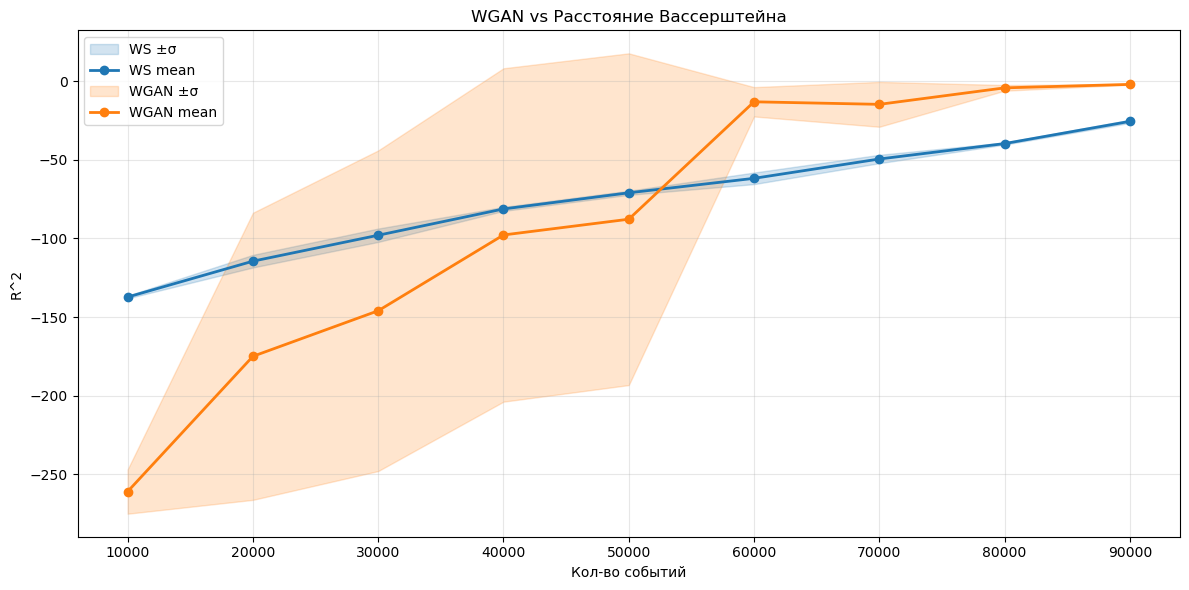

In [22]:
ws_merged = _collect_seed_curves(
    run_dirs=[
        "run_ws_final",
        "run_ws_final_seed_1",
        "run_ws_final_seed_2",
        "run_ws_final_seed_3",
        "run_ws_final_seed_4",
    ],
    experiment_names=[
        "ws_final",
        "ws_final_seed_1",
        "ws_final_seed_2",
        "ws_final_seed_3",
        "ws_final_seed_4",
    ],
    metric="W_r2",
    optimize="max",
)
wgan_merged = _collect_seed_curves(
    run_dirs=[
        "run_wgan_n_critic_5_epochs_200_n_events",
        "run_wgan_n_critic_5_epochs_200_n_events_seed_1",
        "run_wgan_n_critic_5_epochs_200_n_events_seed_2",
        "run_wgan_n_critic_5_epochs_200_n_events_seed_3",
        "run_wgan_n_critic_5_epochs_200_n_events_seed_4",
    ],
    experiment_names=[
        "wgan_n_critic_5_epochs_200_n_events",
        "wgan_n_critic_5_epochs_200_n_events_seed_1",
        "wgan_n_critic_5_epochs_200_n_events_seed_2",
        "wgan_n_critic_5_epochs_200_n_events_seed_3",
        "wgan_n_critic_5_epochs_200_n_events_seed_4",
    ],
    metric="W_r2",
    optimize="max",
)
wgan_merged = wgan_merged[wgan_merged["param_value"] != 100000].reset_index(drop=True)

plt.figure(figsize=(12, 6))

plt.fill_between(ws_merged["param_value"], ws_merged["lo"], ws_merged["hi"], alpha=0.2, color="tab:blue", label="WS ±σ")
plt.plot(ws_merged["param_value"], ws_merged["mean"], marker="o", linewidth=2, color="tab:blue", label="WS mean")

plt.fill_between(wgan_merged["param_value"], wgan_merged["lo"], wgan_merged["hi"], alpha=0.2, color="tab:orange", label="WGAN ±σ")
plt.plot(wgan_merged["param_value"], wgan_merged["mean"], marker="o", linewidth=2, color="tab:orange", label="WGAN mean")

plt.xlabel("Кол-во событий")
plt.ylabel("R^2")
plt.title("WGAN vs Расстояние Вассерштейна")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


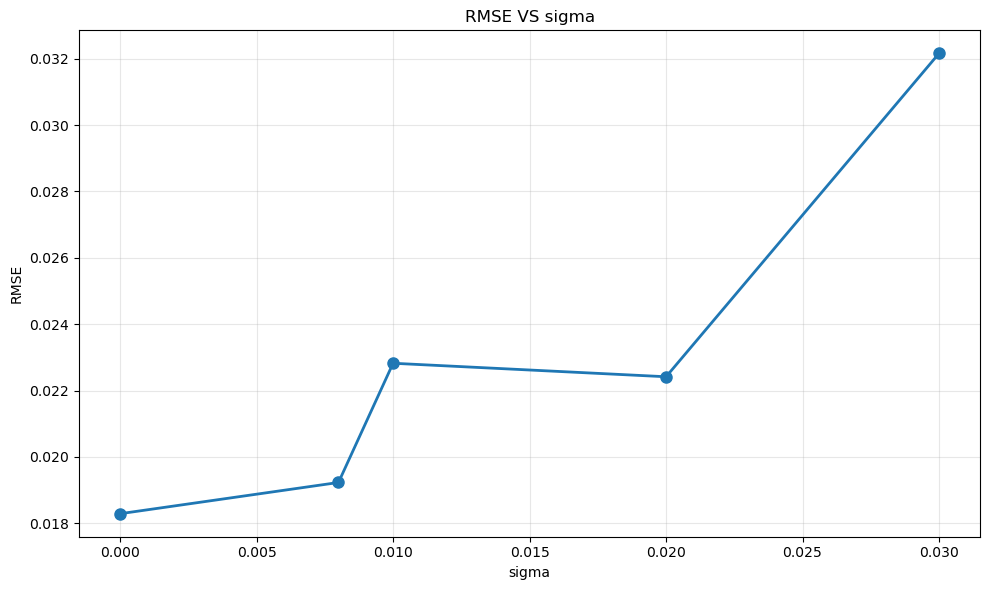

Best overall (min) W_rmse: 0.019232 | sigma=0.008 | config=config_sigma0p008


In [14]:
import math

_baseline_csv = (
    resolve_project_root()
    / "results/run_wgan_n_critic_5_epochs_200_n_events"
    / "wgan_n_critic_5_epochs_200_n_events/config_n90000/wgan_predictions.csv"
)
_df_baseline = pd.read_csv(_baseline_csv)
_baseline_rmse = math.sqrt((((_df_baseline["a_true"] - _df_baseline["a_pred"]) ** 2).mean()))

plot_best_metric_vs_param(
    metric="W_rmse",
    run_dir="run_wgan_noise",
    param_name="sigma",
    optimize="min",
    experiment_name="wgan_noise",
    baseline_point=(0.0, _baseline_rmse),
)

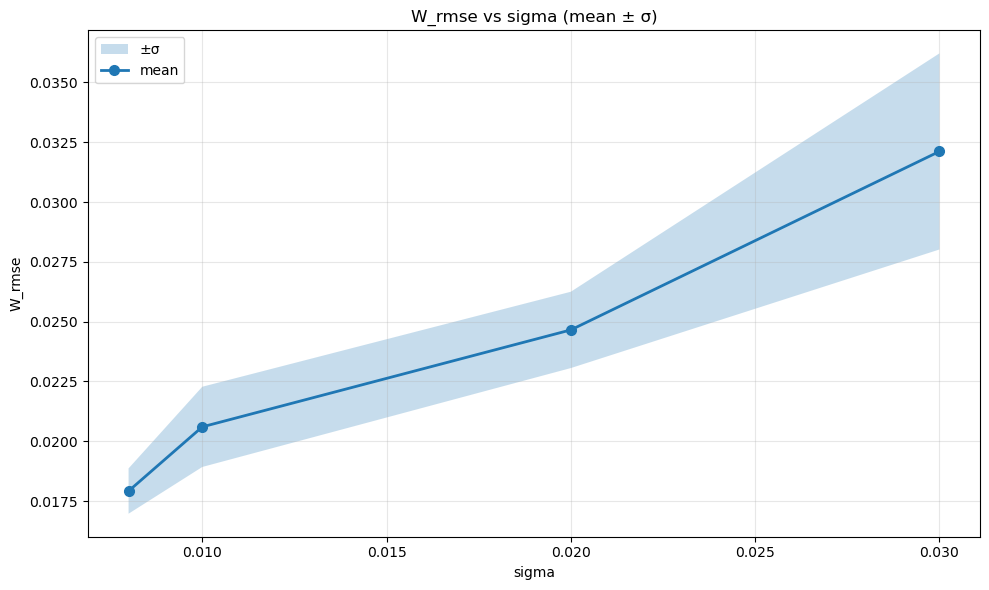

 param_value  wgan_noise  wgan_noise_seed_1  wgan_noise_seed_2     mean      std       lo       hi
       0.008    0.019232           0.017503           0.017028 0.017921 0.000947 0.016974 0.018868
       0.010    0.022824           0.020215           0.018773 0.020604 0.001677 0.018928 0.022281
       0.020    0.022417           0.026013           0.025540 0.024657 0.001595 0.023062 0.026252
       0.030    0.032161           0.037114           0.027074 0.032117 0.004099 0.028018 0.036215


In [7]:
plot_best_metric_vs_param_multi_seed(
    metric="W_rmse",
    run_dirs=[
        "run_wgan_noise",
        "run_wgan_noise_seed_1",
        "run_wgan_noise_seed_2",
    ],
    experiment_names=[
        "wgan_noise",
        "wgan_noise_seed_1",
        "wgan_noise_seed_2",
    ],
    labels=["seed 76/93", "seed 12/55", "seed 37/81"],
    param_name="sigma",
    optimize="min",
)


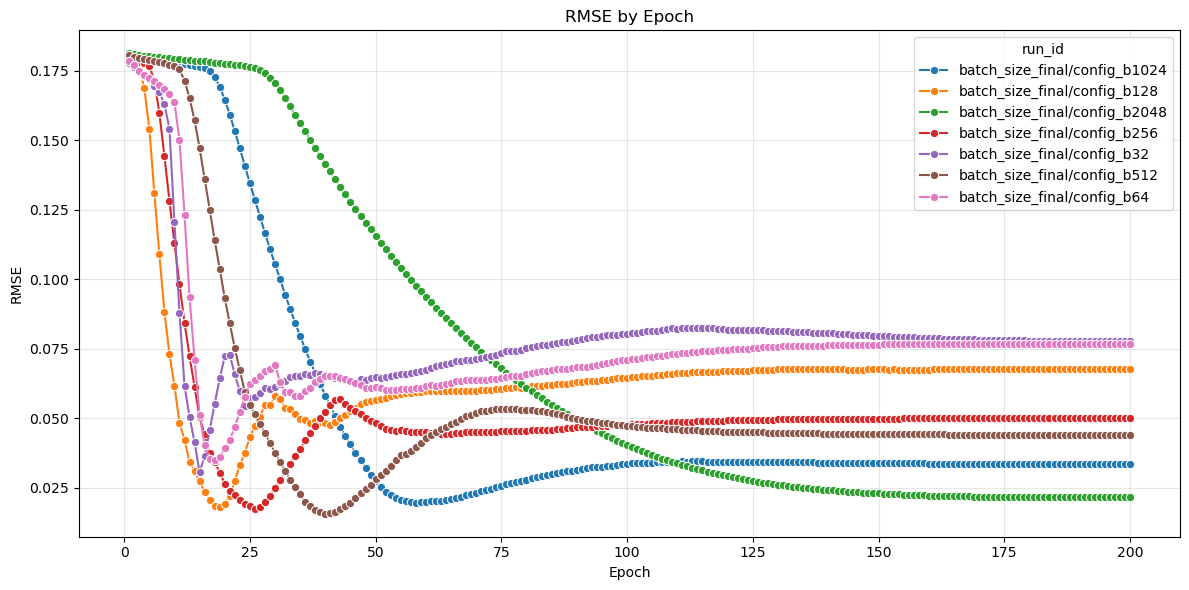

Best (min) W_rmse: 0.015580 | run=batch_size_final/config_b512 | epoch=40


In [2]:
plot_metric_by_epoch(metric="W_rmse", result_subdir="run_batch_size_final", x_axis="epoch")

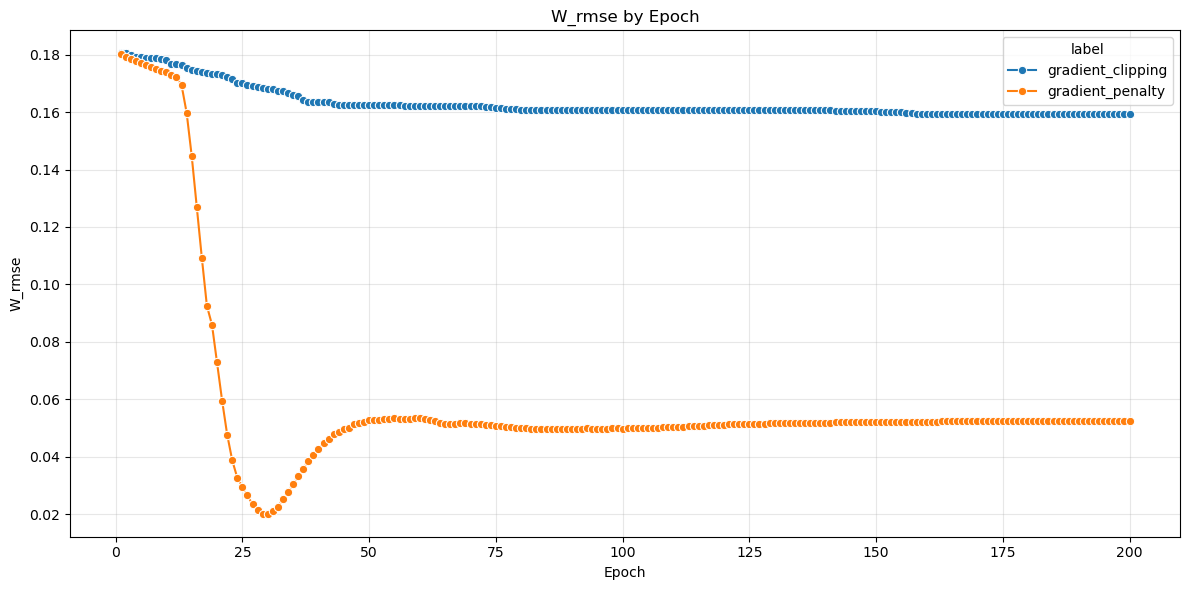

Best (min) W_rmse: 0.159381 | label=gradient_clipping | epoch=197
Best (min) W_rmse: 0.020136 | label=gradient_penalty | epoch=30


In [7]:
_df = load_wgan_histories(resolve_project_root() / "results" / "run_gp_final")
_label_map = {"gp_final/config_true": "gradient_penalty", "gp_final/config_false": "gradient_clipping"}
_df["label"] = _df["run_id"].map(_label_map).fillna(_df["run_id"])

plt.figure(figsize=(12, 6))
sns.lineplot(data=_df, x="epoch", y="W_rmse", hue="label", marker="o")
plt.xlabel("Epoch")
plt.ylabel("W_rmse")
plt.title("W_rmse by Epoch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for lbl, g in _df.groupby("label"):
    idx = g["W_rmse"].idxmin()
    print(f"Best (min) W_rmse: {g.loc[idx, 'W_rmse']:.6f} | label={lbl} | epoch={g.loc[idx, 'epoch']}")

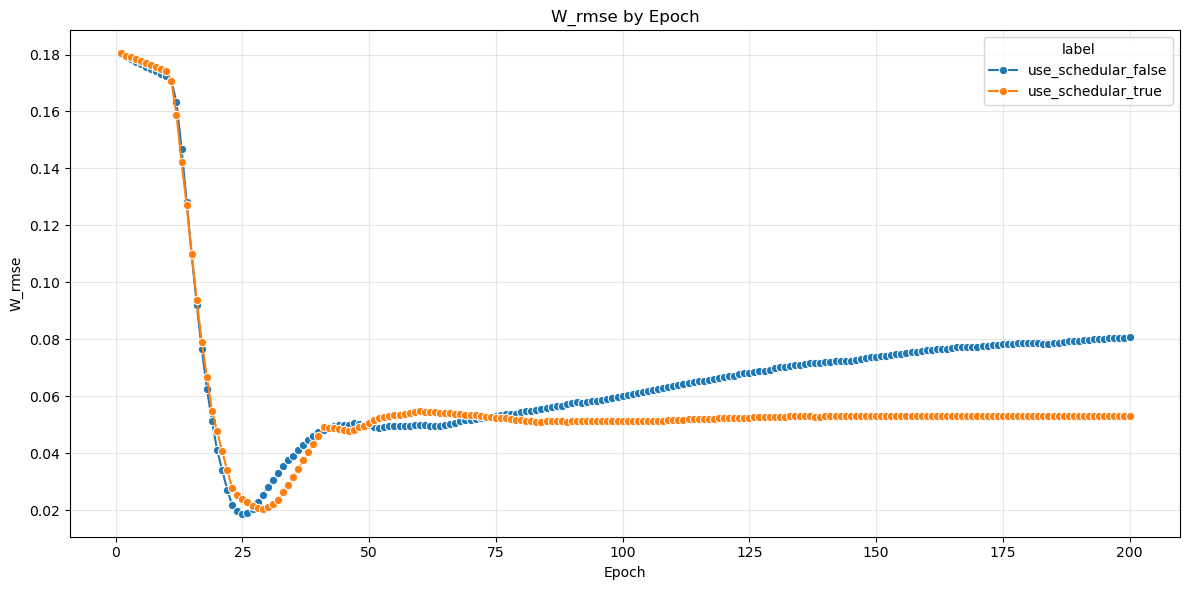

Best (min) W_rmse: 0.018733 | label=use_schedular_false | epoch=25
Best (min) W_rmse: 0.020541 | label=use_schedular_true | epoch=29


In [8]:
_df = load_wgan_histories(resolve_project_root() / "results" / "run_use_schedular_final")
_label_map = {"use_schedular_final/config_true": "use_schedular_true", "use_schedular_final/config_false": "use_schedular_false"}
_df["label"] = _df["run_id"].map(_label_map).fillna(_df["run_id"])

plt.figure(figsize=(12, 6))
sns.lineplot(data=_df, x="epoch", y="W_rmse", hue="label", marker="o")
plt.xlabel("Epoch")
plt.ylabel("W_rmse")
plt.title("W_rmse by Epoch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for lbl, g in _df.groupby("label"):
    idx = g["W_rmse"].idxmin()
    print(f"Best (min) W_rmse: {g.loc[idx, 'W_rmse']:.6f} | label={lbl} | epoch={g.loc[idx, 'epoch']}")

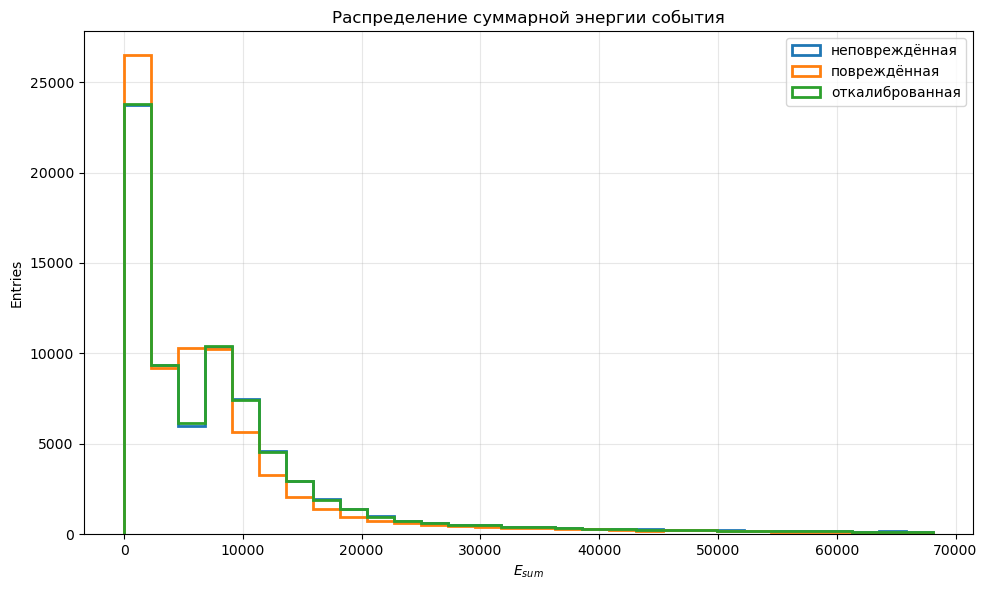

In [ ]:
import sys

project_root = resolve_project_root()
sys.path.insert(0, str(project_root / "scripts"))

from utils import AgingFactorGenerator, filter_by_xyz


def plot_undamaged_vs_calibrated(
    run_dir: str,
    experiment_name: str,
    config_name: str = "config_n90000",
    figsize=(10, 6),
    bins: int = 30,
    quantile: float = 0.99,
):
    """Гистограммы суммарной энергии события: неповреждённая, повреждённая, откалиброванная.

    Для каждого события суммируется энергия по ячейкам, попавшим в фильтр по x/y/z.
    калиброванная = E_old / a_pred, где a_pred берётся из wgan_predictions.csv.
    """
    import numpy as np

    project_root = resolve_project_root()
    config_path = project_root / "configs" / "generated" / experiment_name / f"{config_name}.yaml"
    with open(config_path, "r") as f:
        cfg = yaml.safe_load(f)

    pred_path = project_root / "results" / run_dir / experiment_name / config_name / "wgan_predictions.csv"
    pred_df = pd.read_csv(pred_path)

    raw_df = pd.read_csv(project_root / cfg["data_path"])

    aging_cfg = cfg.get("aging", {})
    generator = AgingFactorGenerator(
        aging_function=aging_cfg.get("function", "xyz"),
        af_min=aging_cfg.get("af_min", 0.8),
        af_max=aging_cfg.get("af_max", 1.0),
        add_noise=aging_cfg.get("sigma", 0.0) > 0.0,
        sigma=aging_cfg.get("sigma", 0.0),
        noise_seed=aging_cfg.get("noise_seed", 42),
        event_col=aging_cfg.get("event_col", "event"),
        x_col=aging_cfg.get("x_col", "x"),
        y_col=aging_cfg.get("y_col", "y"),
        z_col=aging_cfg.get("z_col", "z"),
        energy_col=aging_cfg.get("energy_col", "E"),
    )
    aged = generator.generate(raw_df)

    flt = cfg.get("wgan_params", {}).get("filter", {})
    aged = filter_by_xyz(
        aged,
        x_range=flt.get("x_range"),
        y_range=flt.get("y_range"),
        z_range=flt.get("z_range"),
    )

    merged = aged.merge(pred_df[["x", "y", "z", "a_pred"]], on=["x", "y", "z"], how="inner")
    merged = merged[merged["a_pred"] > 0]
    merged["calibrated"] = merged["E_old"] / merged["a_pred"]

    event_col = aging_cfg.get("event_col", "event")
    sums = merged.groupby(event_col).agg(
        undamaged=("E_new", "sum"),
        damaged=("E_old", "sum"),
        calibrated=("calibrated", "sum"),
    )

    e_undamaged = sums["undamaged"].to_numpy()
    e_damaged = sums["damaged"].to_numpy()
    e_calibrated = sums["calibrated"].to_numpy()

    all_vals = np.concatenate([e_undamaged, e_damaged, e_calibrated])
    hi = float(np.quantile(all_vals, quantile))
    edges = np.linspace(0.0, hi, bins + 1)

    plt.figure(figsize=figsize)
    plt.hist(e_undamaged, bins=edges, histtype="step", linewidth=2, label="неповреждённая")
    plt.hist(e_damaged, bins=edges, histtype="step", linewidth=2, label="повреждённая")
    plt.hist(e_calibrated, bins=edges, histtype="step", linewidth=2, label="откалиброванная")
    plt.xlabel(r"$E_{sum}$")
    plt.ylabel("Entries")
    plt.title("Распределение суммарной энергии события")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_undamaged_vs_calibrated(
    run_dir="run_wgan_n_critic_5_epochs_200_n_events",
    experiment_name="wgan_n_critic_5_epochs_200_n_events",
    config_name="config_n90000",
)

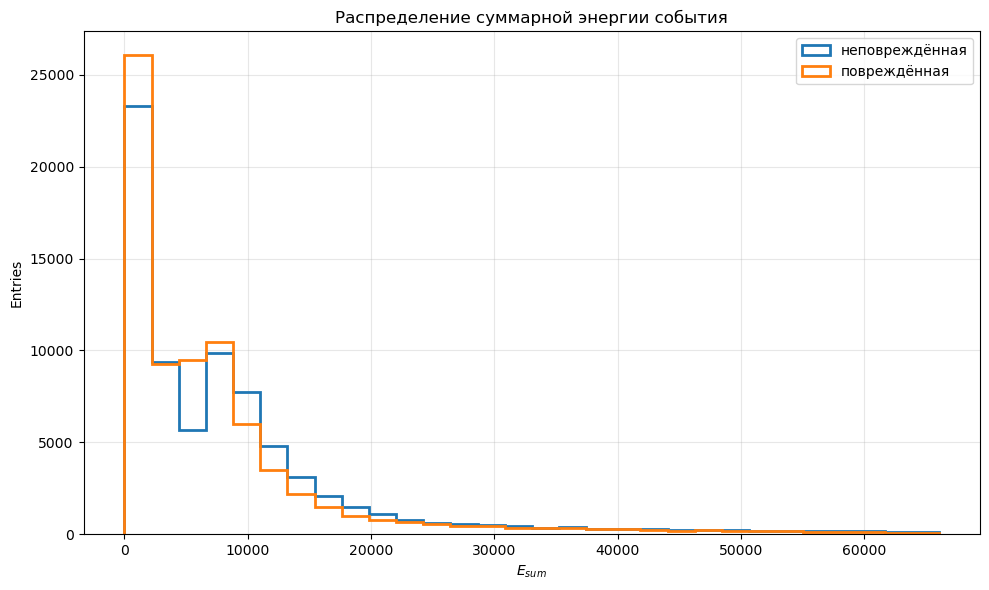

In [33]:
def plot_undamaged_vs_damaged(
    run_dir: str,
    experiment_name: str,
    config_name: str = "config_n90000",
    figsize=(10, 6),
    bins: int = 30,
    quantile: float = 0.99,
):
    """Гистограммы суммарной энергии события: неповреждённая и повреждённая.

    Берётся тот же набор ячеек, что и в `plot_undamaged_vs_calibrated`
    (фильтр x/y/z из конфига + только клетки, попавшие в wgan_predictions.csv),
    чтобы сравнение было по одинаковой выборке.
    """
    import numpy as np

    project_root = resolve_project_root()
    config_path = project_root / "configs" / "generated" / experiment_name / f"{config_name}.yaml"
    with open(config_path, "r") as f:
        cfg = yaml.safe_load(f)

    pred_path = project_root / "results" / run_dir / experiment_name / config_name / "wgan_predictions.csv"
    pred_df = pd.read_csv(pred_path)

    raw_df = pd.read_csv(project_root / cfg["data_path"])

    aging_cfg = cfg.get("aging", {})
    generator = AgingFactorGenerator(
        aging_function=aging_cfg.get("function", "xyz"),
        af_min=aging_cfg.get("af_min", 0.8),
        af_max=aging_cfg.get("af_max", 1.0),
        add_noise=aging_cfg.get("sigma", 0.0) > 0.0,
        sigma=aging_cfg.get("sigma", 0.0),
        noise_seed=aging_cfg.get("noise_seed", 42),
        event_col=aging_cfg.get("event_col", "event"),
        x_col=aging_cfg.get("x_col", "x"),
        y_col=aging_cfg.get("y_col", "y"),
        z_col=aging_cfg.get("z_col", "z"),
        energy_col=aging_cfg.get("energy_col", "E"),
    )
    aged = generator.generate(raw_df)

    flt = cfg.get("wgan_params", {}).get("filter", {})
    aged = filter_by_xyz(
        aged,
        x_range=flt.get("x_range"),
        y_range=flt.get("y_range"),
        z_range=flt.get("z_range"),
    )

    merged = aged.merge(pred_df[["x", "y", "z"]], on=["x", "y", "z"], how="inner")

    event_col = aging_cfg.get("event_col", "event")
    sums = merged.groupby(event_col).agg(
        undamaged=("E_new", "sum"),
        damaged=("E_old", "sum"),
    )

    e_undamaged = sums["undamaged"].to_numpy()
    e_damaged = sums["damaged"].to_numpy()

    all_vals = np.concatenate([e_undamaged, e_damaged])
    hi = float(np.quantile(all_vals, quantile))
    edges = np.linspace(0.0, hi, bins + 1)

    plt.figure(figsize=figsize)
    plt.hist(e_undamaged, bins=edges, histtype="step", linewidth=2, label="неповреждённая")
    plt.hist(e_damaged, bins=edges, histtype="step", linewidth=2, label="повреждённая")
    plt.xlabel(r"$E_{sum}$")
    plt.ylabel("Entries")
    plt.title("Распределение суммарной энергии события")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_undamaged_vs_damaged(
    run_dir="run_wgan_n_critic_5_epochs_200_n_events",
    experiment_name="wgan_n_critic_5_epochs_200_n_events",
    config_name="config_n90000",
)
